# 📚 Data Science — Chatbot Edukatif IPA SD
**Coding Camp 2026 powered by DBS Foundation**  
**ID Tim: CC26-PSU312** | Tema: Accessible & Adaptive Learning

---

## 🎯 Tujuan Notebook
Notebook ini mencakup seluruh pipeline Data Science mulai dari:
1. Problem Definition & Business Questions
2. Data Gathering
3. Data Assessing (Pemeriksaan Kualitas Data)
4. Data Wrangling / Cleaning
5. Exploratory Data Analysis (EDA)
6. Explanatory Analysis & Visualisasi
7. Feature Engineering
8. Data Dictionary
9. Export Data Bersih

---
## 1️⃣ Problem Definition

### Latar Belakang
Banyak siswa SD mengalami kesulitan memahami konsep IPA yang bersifat abstrak.
Proyek ini mengembangkan **chatbot edukatif** berbasis kuis adaptif.
Peran Data Science adalah memastikan dataset Q&A IPA berkualitas tinggi dan siap digunakan sebagai bahan training model AI.

### Business Questions
1. Topik IPA apa yang paling banyak dibahas dalam dataset?
2. Bagaimana distribusi panjang soal dan jawaban?
3. Subtopik mana yang memiliki jumlah soal terbanyak?
4. Apakah ada ketidakkonsistenan penulisan topik (duplikat semantik)?
5. Bagaimana distribusi kompleksitas soal berdasarkan panjang teks?

---
## 2️⃣ Import Library

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
import warnings
import os
import re

warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
PALETTE = sns.color_palette('Set2')
sns.set_palette(PALETTE)

print('✅ Library berhasil diimport')

✅ Library berhasil diimport


---
## 3️⃣ Data Gathering — Memuat Dataset

In [52]:
from pathlib import Path

# Load dataset — path fleksibel + fallback encoding
candidate_paths = [
    Path('datasoal.csv'),
    Path('data/datasoal.csv'),
    Path('../data/datasoal.csv'),
]
DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        'datasoal.csv tidak ditemukan. Taruh berkas di salah satu: '
        + ', '.join(str(p) for p in candidate_paths)
    )

_last_decode = None
for enc in ('utf-8', 'utf-8-sig', 'cp1252', 'latin1'):
    try:
        df_raw = pd.read_csv(DATA_PATH, encoding=enc)
        print(f'✅ Dataset dari {DATA_PATH} (encoding: {enc})')
        break
    except UnicodeDecodeError as e:
        _last_decode = e
else:
    raise _last_decode

print(f'📊 Jumlah baris   : {df_raw.shape[0]:,}')
print(f'📋 Jumlah kolom   : {df_raw.shape[1]}')
print(f'\n📝 Kolom: {df_raw.columns.tolist()}')
df_raw.head(3)

✅ Dataset dari datasoal.csv (encoding: utf-8)
📊 Jumlah baris   : 3,349
📋 Jumlah kolom   : 8

📝 Kolom: ['no', 'topik', 'subtopik', 'soal', 'jawaban', 'contoh', 'konteks', 'link_sumber']


,no,topik,subtopik,soal,jawaban,contoh,konteks,link_sumber
0,1,adaptasi makhluk hidup,adaptasi makhluk hidup,apa yang dimaksud dengan adaptasi?,proses penyesuaian diri makhluk hidup atau ind...,kaktus mampu hidup di daerah kering karena mem...,adaptasi bertujuan mempertahankan hidup.,https://www.omahbse.com/ktsp/file/sd-5_ipa_002/
1,2,adaptasi makhluk hidup,adaptasi makhluk hidup,apa pengertian adaptasi?,proses penyesuaian diri makhluk hidup atau ind...,kaktus mampu hidup di daerah kering karena mem...,adaptasi bertujuan mempertahankan hidup.,https://www.omahbse.com/ktsp/file/sd-5_ipa_002/
2,3,adaptasi makhluk hidup,adaptasi makhluk hidup,jelaskan adaptasi.,proses penyesuaian diri makhluk hidup atau ind...,kaktus mampu hidup di daerah kering karena mem...,adaptasi bertujuan mempertahankan hidup.,https://www.omahbse.com/ktsp/file/sd-5_ipa_002/


In [53]:
# Sumber data (CSV bisa memakai `link_sumber` atau `link sumber buku`)
link_col = 'link_sumber' if 'link_sumber' in df_raw.columns else 'link sumber buku'
print('🔗 Sumber Data Unik:')
for url in df_raw[link_col].dropna().unique():
    print(f'  → {url}')

🔗 Sumber Data Unik:
  → https://www.omahbse.com/ktsp/file/sd-5_ipa_002/
  → https://www.omahbse.com/ktsp/file/sd-5_ipa_013/
  → https://www.omahbse.com/ktsp/file/sd-5_ipa_012/
  → https://www.omahbse.com/ktsp/file/sd-5_ipa_007/view/
  → https://www.omahbse.com/ktsp/file/sd-5_ipa_006/
  → https://www.omahbse.com/ktsp/file/sd-5_ipa_001/
  → https://www.omahbse.com/ktsp/file/sd-5_ipa_005/
  → https://www.omahbse.com/ktsp/file/sd-5_ipa_007/


---
## 4️⃣ Data Assessing — Pemeriksaan Kualitas Data

In [28]:
print('=' * 55)
print('📋 INFO DATASET')
print('=' * 55)
df_raw.info()

📋 INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3349 entries, 0 to 3348
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   no           3349 non-null   int64 
 1   topik        3349 non-null   object
 2   subtopik     3349 non-null   object
 3   soal         3349 non-null   object
 4   jawaban      3349 non-null   object
 5   contoh       3349 non-null   object
 6   konteks      3349 non-null   object
 7   link_sumber  3349 non-null   object
dtypes: int64(1), object(7)
memory usage: 209.4+ KB


In [29]:
print('=' * 55)
print('🔍 PEMERIKSAAN MISSING VALUES')
print('=' * 55)
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
print(missing_df)

if missing.sum() == 0:
    print('\n✅ Tidak ada missing values!')
else:
    print(f'\n⚠️  Total missing: {missing.sum()}')

🔍 PEMERIKSAAN MISSING VALUES
             Jumlah Missing  Persentase (%)
no                        0             0.0
topik                     0             0.0
subtopik                  0             0.0
soal                      0             0.0
jawaban                   0             0.0
contoh                    0             0.0
konteks                   0             0.0
link_sumber               0             0.0

✅ Tidak ada missing values!


In [30]:
print('=' * 55)
print('🔁 PEMERIKSAAN DUPLIKASI')
print('=' * 55)
dup_rows = df_raw.duplicated().sum()
dup_soal = df_raw['soal'].duplicated().sum()

print(f'Baris duplikat penuh    : {dup_rows}')
print(f'Soal duplikat (teks sama): {dup_soal}')

if dup_soal > 0:
    print(f'\n⚠️  Contoh soal duplikat:')
    dup_examples = df_raw[df_raw['soal'].duplicated(keep=False)].sort_values('soal')
    print(dup_examples[['no','topik','soal']].head(4).to_string(index=False))

🔁 PEMERIKSAAN DUPLIKASI
Baris duplikat penuh    : 0
Soal duplikat (teks sama): 500

⚠️  Contoh soal duplikat:
  no                   topik                                                               soal
 959      benda dan sifatnya antara kertas, benang, dan tali, manakah yang paling sulit diputus
 957      benda dan sifatnya antara kertas, benang, dan tali, manakah yang paling sulit diputus
1340 bumi dan peristiwa alam                        apa alasan air di bumi tidak habis-habis...
1343 bumi dan peristiwa alam                        apa alasan air di bumi tidak habis-habis...


In [31]:
print('=' * 55)
print('📝 PEMERIKSAAN KONSISTENSI TOPIK')
print('=' * 55)
print(f'Jumlah nilai unik topik  : {df_raw["topik"].nunique()}')
print(f'\nDaftar topik unik:')
for i, t in enumerate(sorted(df_raw['topik'].unique()), 1):
    print(f'  {i:2d}. "{t}"')

📝 PEMERIKSAAN KONSISTENSI TOPIK
Jumlah nilai unik topik  : 15

Daftar topik unik:
   1. "adaptasi makhluk hidup"
   2. "air"
   3. "alat pencernaan dan makanan"
   4. "alat pernapasan manusia dan hewan"
   5. "alat tubuh manusia dan hewan"
   6. "benda dan sifatnya"
   7. "bumi dan peristiwa alam"
   8. "cahaya dan sifat-sifatnya"
   9. "gaya, gerak, dan energi"
  10. "organ tubuh manusia dan hewan"
  11. "peredaran darah"
  12. "peristiwa alam"
  13. "sistem pernapasan"
  14. "sumber daya alam dan kegunaannya"
  15. "tumbuhan hijau"


In [32]:
# Deteksi inkonsistensi kapitalisasi topik
print('⚠️  INKONSISTENSI KAPITALISASI TOPIK (Duplikat Semantik):')
df_raw['topik_lower'] = df_raw['topik'].str.lower().str.strip()
dup_topics = df_raw.groupby('topik_lower')['topik'].unique()
inconsistent = dup_topics[dup_topics.apply(len) > 1]
for key, vals in inconsistent.items():
    print(f'  → "{key}" → ditemukan sebagai: {list(vals)}')

print(f'\n📊 Total inkonsistensi topik: {len(inconsistent)}')
df_raw.drop(columns=['topik_lower'], inplace=True)

⚠️  INKONSISTENSI KAPITALISASI TOPIK (Duplikat Semantik):

📊 Total inkonsistensi topik: 0


---
## 5️⃣ Data Wrangling / Cleaning

In [ ]:
df = df_raw.copy()
issues_fixed = []

if "link sumber buku" in df.columns:
    df.rename(columns={"link sumber buku": "link_sumber"}, inplace=True)
elif "link_sumber" not in df.columns:
    issues_fixed.append("Peringatan: kolom URL sumber tidak ditemukan")

# --- 1. Normalisasi teks kolom topik & subtopik ---
before_unique = df['topik'].nunique()
df['topik'] = df['topik'].str.lower().str.strip()
df['subtopik'] = df['subtopik'].str.lower().str.strip()
after_unique = df['topik'].nunique()
issues_fixed.append(f'Normalisasi topik: {before_unique} → {after_unique} nilai unik')

# --- 2. Trim whitespace pada semua kolom teks ---
text_cols = ['soal', 'jawaban', 'contoh', 'konteks']
for col in text_cols:
    df[col] = df[col].str.strip()
issues_fixed.append('Trim whitespace pada kolom teks (soal, jawaban, contoh, konteks)')

# --- 3. Pertahankan semua baris; tandai baris berganda dengan teks soal sama ---
before_len = len(df)
df["duplikat_soal"] = df.duplicated(subset=["soal"], keep="first")
n_dup_extra = int(df["duplikat_soal"].sum())
n_uniq_soal = df["soal"].nunique()
issues_fixed.append(
    f"Duplikasi soal: {n_dup_extra} baris duplikat, {n_uniq_soal} teks soal unik ({before_len} baris total dimuat)"
)

# --- 4. Reset nomor urut ---
df["no"] = range(1, len(df) + 1)
issues_fixed.append("Reset kolom no (nomor urut)")

print('✅ HASIL DATA CLEANING:')
for i, fix in enumerate(issues_fixed, 1):
    print(f'  {i}. {fix}')

print(f'\n📊 Ukuran dataset: {df_raw.shape} → {df.shape}')

✅ HASIL DATA CLEANING:
  1. Normalisasi topik: 15 → 15 nilai unik
  2. Trim whitespace pada kolom teks (soal, jawaban, contoh, konteks)
  3. Hapus soal duplikat: 500 baris dihapus (2849 tersisa)
  4. Reset kolom no (nomor urut)
  5. Rename "link sumber buku" → "link_sumber"

📊 Ukuran dataset: (3349, 8) → (2849, 8)


In [ ]:
# Verifikasi hasil cleaning
print('🔍 Verifikasi Pasca Cleaning:')
print(f'  Missing values                  : {df.isnull().sum().sum()}')
print(f"  Baris duplikat (`duplikat_soal`): {int(df['duplikat_soal'].sum())}")
print(f"  Teks soal unik                  : {df['soal'].nunique()}")
print(f'  Topik unik      : {df["topik"].nunique()}')
df.head(3)

🔍 Verifikasi Pasca Cleaning:
  Missing values  : 0
  Duplikat soal   : 0
  Topik unik      : 15


,no,topik,subtopik,soal,jawaban,contoh,konteks,link_sumber
0,1,adaptasi makhluk hidup,adaptasi makhluk hidup,apa yang dimaksud dengan adaptasi?,proses penyesuaian diri makhluk hidup atau ind...,kaktus mampu hidup di daerah kering karena mem...,adaptasi bertujuan mempertahankan hidup.,https://www.omahbse.com/ktsp/file/sd-5_ipa_002/
1,2,adaptasi makhluk hidup,adaptasi makhluk hidup,apa pengertian adaptasi?,proses penyesuaian diri makhluk hidup atau ind...,kaktus mampu hidup di daerah kering karena mem...,adaptasi bertujuan mempertahankan hidup.,https://www.omahbse.com/ktsp/file/sd-5_ipa_002/
2,3,adaptasi makhluk hidup,adaptasi makhluk hidup,jelaskan adaptasi.,proses penyesuaian diri makhluk hidup atau ind...,kaktus mampu hidup di daerah kering karena mem...,adaptasi bertujuan mempertahankan hidup.,https://www.omahbse.com/ktsp/file/sd-5_ipa_002/


---
## 6️⃣ Feature Engineering

In [36]:
# Fitur panjang teks
df['panjang_soal']    = df['soal'].str.len()
df['panjang_jawaban'] = df['jawaban'].str.len()
df['panjang_konteks'] = df['konteks'].str.len()

# Fitur jumlah kata
df['kata_soal']    = df['soal'].str.split().str.len()
df['kata_jawaban'] = df['jawaban'].str.split().str.len()

# Fitur jenis pertanyaan
def jenis_pertanyaan(soal):
    soal_lower = soal.lower()
    if soal_lower.startswith('apa'):
        return 'apa'
    elif soal_lower.startswith('bagaimana'):
        return 'bagaimana'
    elif soal_lower.startswith('mengapa'):
        return 'mengapa'
    elif soal_lower.startswith('sebutkan'):
        return 'sebutkan'
    elif soal_lower.startswith('jelaskan'):
        return 'jelaskan'
    elif soal_lower.startswith('berapa'):
        return 'berapa'
    else:
        return 'lainnya'

df['jenis_pertanyaan'] = df['soal'].apply(jenis_pertanyaan)

# Tingkat kompleksitas soal berdasarkan jumlah kata
def tingkat_kompleksitas(n_kata):
    if n_kata <= 6:
        return 'Mudah'
    elif n_kata <= 10:
        return 'Sedang'
    else:
        return 'Kompleks'

df['kompleksitas'] = df['kata_soal'].apply(tingkat_kompleksitas)

print('✅ Feature engineering selesai. Fitur baru:')
new_feats = ['panjang_soal','panjang_jawaban','panjang_konteks',
             'kata_soal','kata_jawaban','jenis_pertanyaan','kompleksitas']
for f in new_feats:
    print(f'  + {f}')
df[new_feats].head(4)

✅ Feature engineering selesai. Fitur baru:
  + panjang_soal
  + panjang_jawaban
  + panjang_konteks
  + kata_soal
  + kata_jawaban
  + jenis_pertanyaan
  + kompleksitas


,panjang_soal,panjang_jawaban,panjang_konteks,kata_soal,kata_jawaban,jenis_pertanyaan,kompleksitas
0,34,136,40,5,19,apa,Mudah
1,24,136,40,3,19,apa,Mudah
2,18,136,40,2,19,jelaskan,Mudah
3,40,72,54,5,9,mengapa,Mudah


---
## 7️⃣ Exploratory Data Analysis (EDA)

In [37]:
print('=' * 55)
print('📊 STATISTIK DESKRIPTIF — FITUR NUMERIK')
print('=' * 55)
df[['panjang_soal','panjang_jawaban','kata_soal','kata_jawaban']].describe().round(2)

📊 STATISTIK DESKRIPTIF — FITUR NUMERIK


,panjang_soal,panjang_jawaban,kata_soal,kata_jawaban
count,2849.00,2849.00,2849.00,2849.00
mean,48.91,98.15,7.01,13.59
std,18.51,66.91,2.63,9.32
min,13.00,3.00,2.00,1.00
25%,34.00,48.00,5.00,7.00
50%,46.00,83.00,7.00,11.00
75%,60.00,152.00,8.00,21.00
max,133.00,314.00,18.00,45.00


In [38]:
print('📋 DISTRIBUSI TOPIK:')
topic_count = df['topik'].value_counts()
print(topic_count.to_string())

📋 DISTRIBUSI TOPIK:
topik
benda dan sifatnya                   354
gaya, gerak, dan energi              328
bumi dan peristiwa alam              263
tumbuhan hijau                       238
cahaya dan sifat-sifatnya            212
alat tubuh manusia dan hewan         168
peristiwa alam                       163
adaptasi makhluk hidup               161
peredaran darah                      158
air                                  155
sumber daya alam dan kegunaannya     149
alat pernapasan manusia dan hewan    142
sistem pernapasan                    131
organ tubuh manusia dan hewan        118
alat pencernaan dan makanan          109


In [39]:
print('📋 DISTRIBUSI JENIS PERTANYAAN:')
print(df['jenis_pertanyaan'].value_counts())
print()
print('📋 DISTRIBUSI KOMPLEKSITAS SOAL:')
print(df['kompleksitas'].value_counts())

📋 DISTRIBUSI JENIS PERTANYAAN:
jenis_pertanyaan
apa          947
lainnya      867
jelaskan     392
bagaimana    285
mengapa      231
sebutkan     126
berapa         1
Name: count, dtype: int64

📋 DISTRIBUSI KOMPLEKSITAS SOAL:
kompleksitas
Mudah       1327
Sedang      1192
Kompleks     330
Name: count, dtype: int64


---
## 8️⃣ Visualisasi Data (Explanatory Analysis)

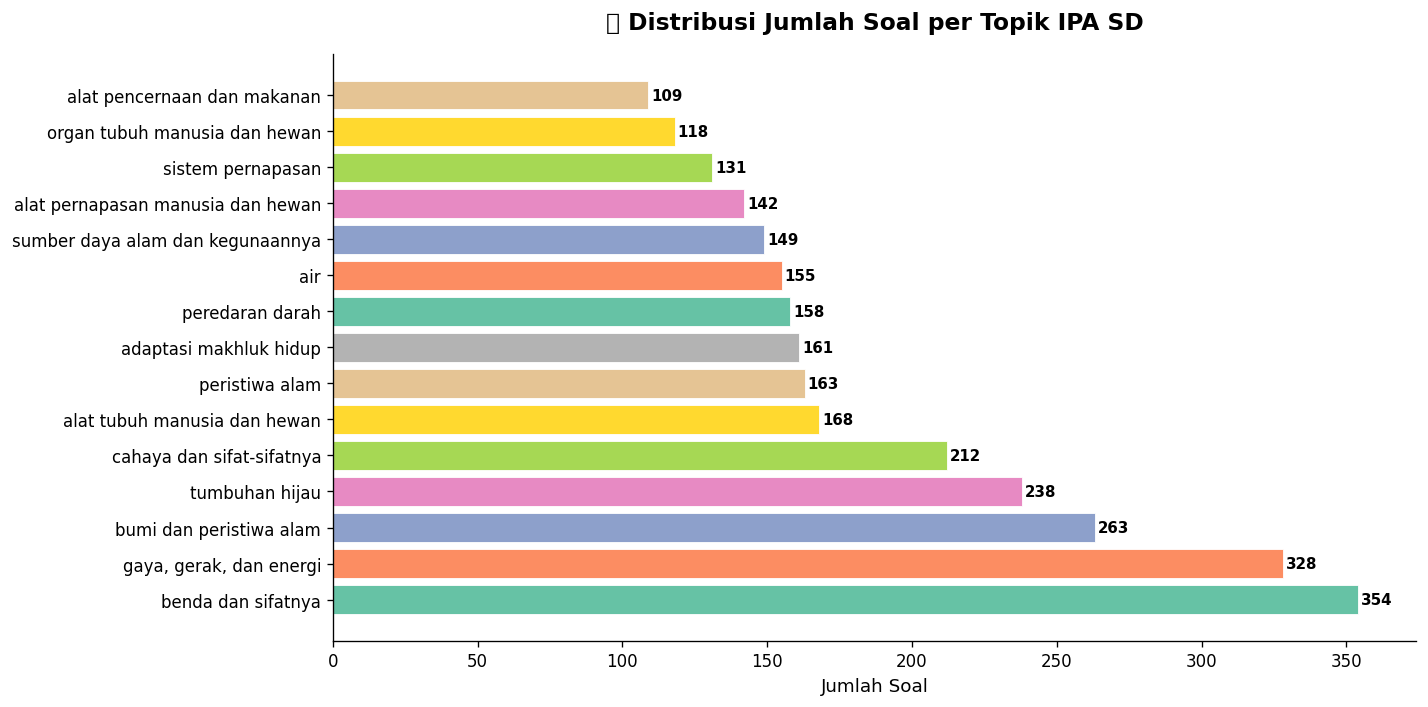

✅ Insight: Topik terbanyak adalah benda dan sifatnya (354 soal)


In [40]:
# --- VISUALISASI 1: Distribusi Jumlah Soal per Topik ---
fig, ax = plt.subplots(figsize=(12, 6))

topic_count = df['topik'].value_counts()
colors = sns.color_palette('Set2', len(topic_count))

bars = ax.barh(topic_count.index, topic_count.values, color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, topic_count.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', ha='left', fontsize=9, fontweight='bold')

ax.set_xlabel('Jumlah Soal', fontsize=11)
ax.set_title('📊 Distribusi Jumlah Soal per Topik IPA SD', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, topic_count.max() + 20)
plt.tight_layout()
plt.savefig('viz_01_distribusi_topik.png', bbox_inches='tight')
plt.show()
print('✅ Insight: Topik terbanyak adalah', topic_count.idxmax(), f'({topic_count.max()} soal)')

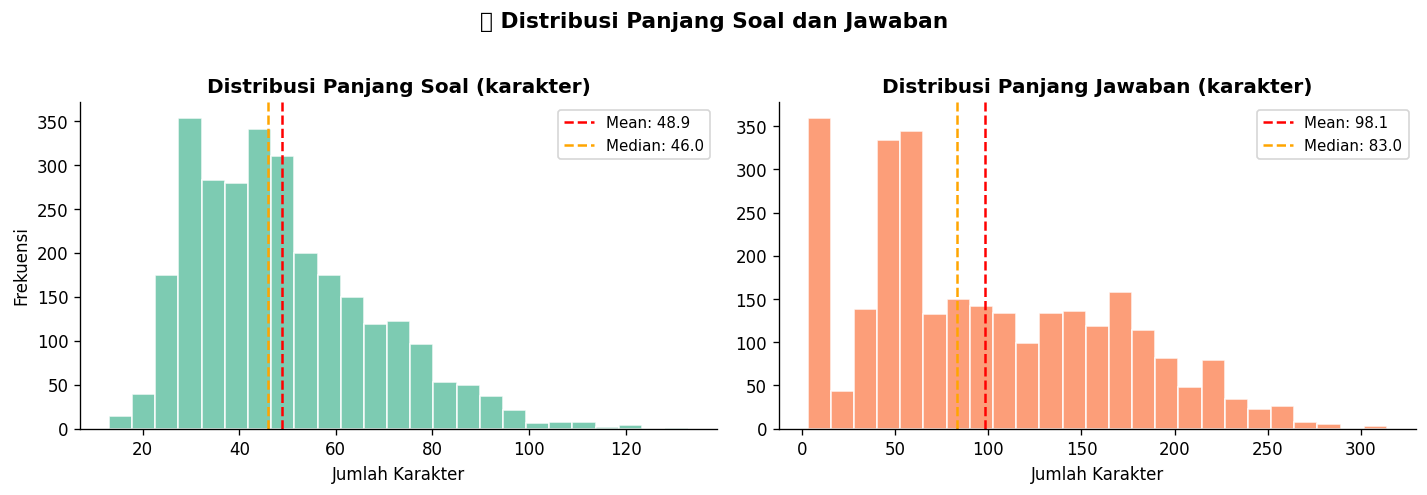

✅ Insight: Rata-rata soal memiliki 49 karakter; rata-rata jawaban 98 karakter


In [41]:
# --- VISUALISASI 2: Distribusi Panjang Soal & Jawaban ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram panjang soal
axes[0].hist(df['panjang_soal'], bins=25, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0].axvline(df['panjang_soal'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean: {df["panjang_soal"].mean():.1f}')
axes[0].axvline(df['panjang_soal'].median(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Median: {df["panjang_soal"].median():.1f}')
axes[0].set_title('Distribusi Panjang Soal (karakter)', fontweight='bold')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')
axes[0].legend(fontsize=9)

# Histogram panjang jawaban
axes[1].hist(df['panjang_jawaban'], bins=25, color=PALETTE[1], edgecolor='white', alpha=0.85)
axes[1].axvline(df['panjang_jawaban'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean: {df["panjang_jawaban"].mean():.1f}')
axes[1].axvline(df['panjang_jawaban'].median(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Median: {df["panjang_jawaban"].median():.1f}')
axes[1].set_title('Distribusi Panjang Jawaban (karakter)', fontweight='bold')
axes[1].set_xlabel('Jumlah Karakter')
axes[1].legend(fontsize=9)

fig.suptitle('📏 Distribusi Panjang Soal dan Jawaban', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_02_distribusi_panjang.png', bbox_inches='tight')
plt.show()
print('✅ Insight: Rata-rata soal memiliki', round(df['panjang_soal'].mean()), 'karakter;',
      'rata-rata jawaban', round(df['panjang_jawaban'].mean()), 'karakter')

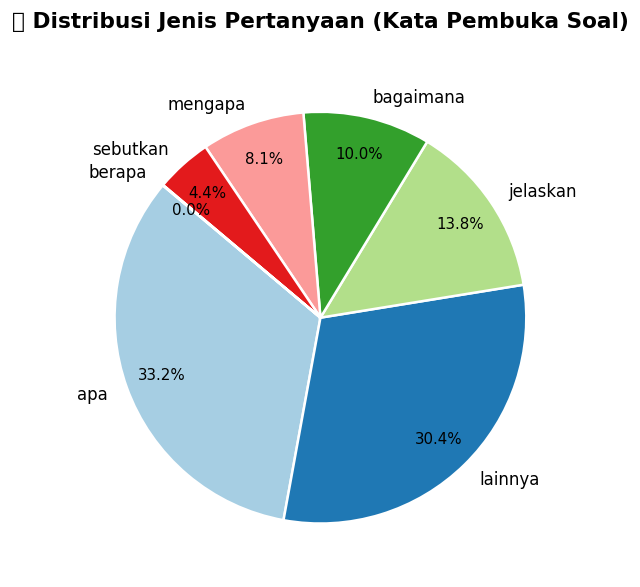

✅ Insight: Pertanyaan terbanyak dimulai dengan kata: apa


In [42]:
# --- VISUALISASI 3: Jenis Pertanyaan ---
fig, ax = plt.subplots(figsize=(8, 5))

jenis_count = df['jenis_pertanyaan'].value_counts()
colors = sns.color_palette('Paired', len(jenis_count))

wedges, texts, autotexts = ax.pie(
    jenis_count.values,
    labels=jenis_count.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.82,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

for at in autotexts:
    at.set_fontsize(9)

ax.set_title('🔤 Distribusi Jenis Pertanyaan (Kata Pembuka Soal)',
             fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('viz_03_jenis_pertanyaan.png', bbox_inches='tight')
plt.show()
print('✅ Insight: Pertanyaan terbanyak dimulai dengan kata:', jenis_count.idxmax())

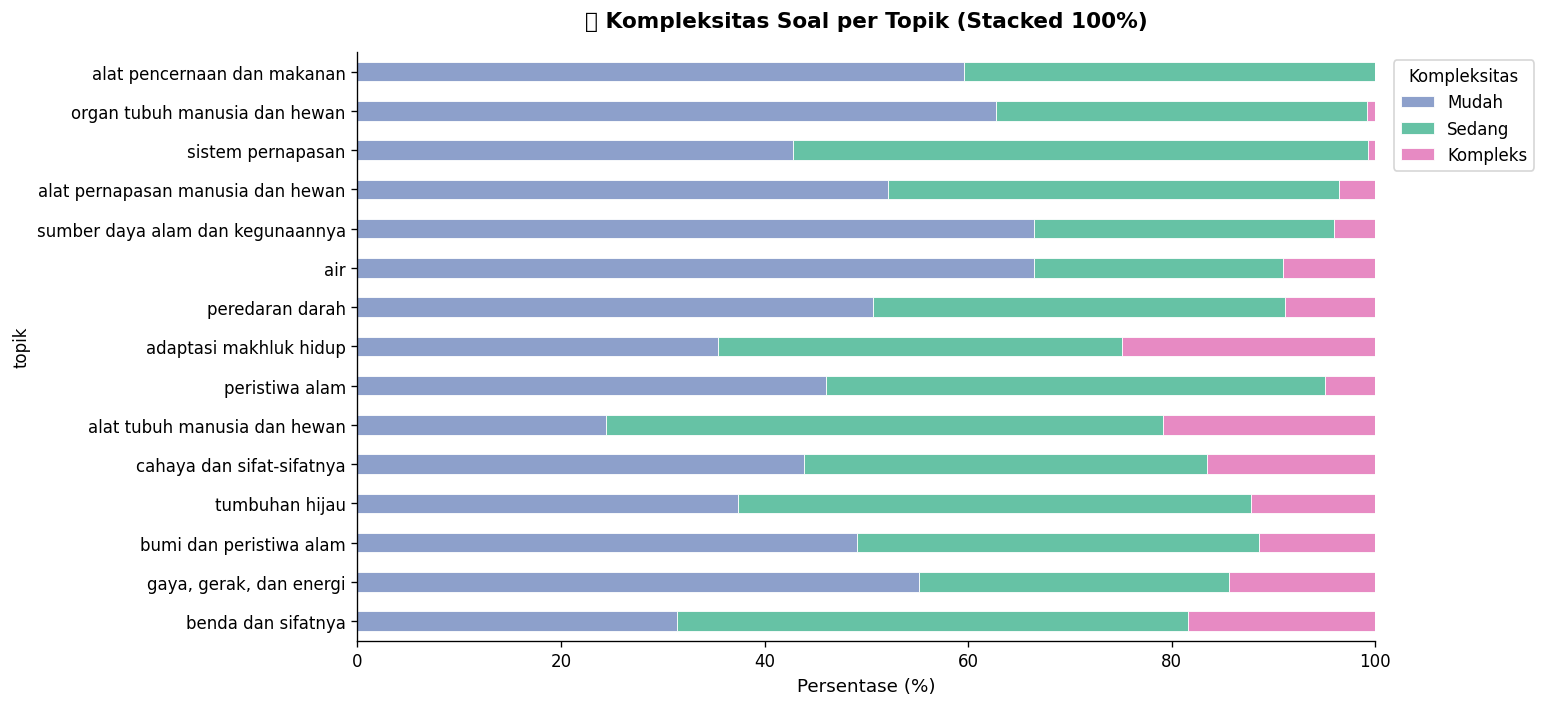

In [43]:
# --- VISUALISASI 4: Kompleksitas Soal per Topik ---
fig, ax = plt.subplots(figsize=(13, 6))

# Pivot table
pivot = df.groupby(['topik', 'kompleksitas']).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=['Mudah', 'Sedang', 'Kompleks'], fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Sort by total
pivot_pct = pivot_pct.loc[df['topik'].value_counts().index]

pivot_pct.plot(kind='barh', stacked=True, ax=ax,
               color=[PALETTE[2], PALETTE[0], PALETTE[3]],
               edgecolor='white', linewidth=0.5)

ax.set_xlabel('Persentase (%)', fontsize=11)
ax.set_title('📊 Kompleksitas Soal per Topik (Stacked 100%)', fontsize=13, fontweight='bold', pad=15)
ax.legend(title='Kompleksitas', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig('viz_04_kompleksitas_topik.png', bbox_inches='tight')
plt.show()

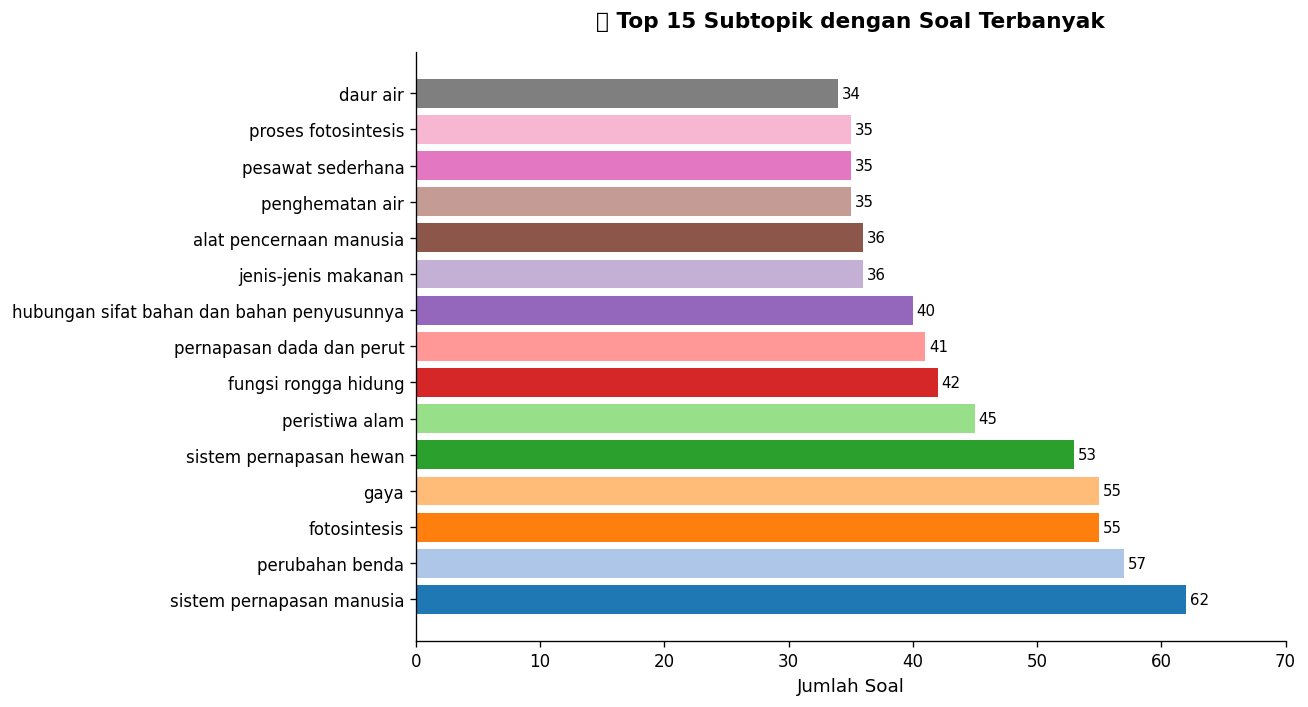

✅ Insight: Subtopik terbanyak adalah: sistem pernapasan manusia (62 soal)


In [44]:
# --- VISUALISASI 5: Top 15 Subtopik ---
fig, ax = plt.subplots(figsize=(11, 6))

top15_subtopik = df['subtopik'].value_counts().head(15)
colors = sns.color_palette('tab20', 15)

bars = ax.barh(top15_subtopik.index, top15_subtopik.values, color=colors)
for bar, val in zip(bars, top15_subtopik.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', ha='left', fontsize=9)

ax.set_xlabel('Jumlah Soal', fontsize=11)
ax.set_title('🔎 Top 15 Subtopik dengan Soal Terbanyak', fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, top15_subtopik.max() + 8)
plt.tight_layout()
plt.savefig('viz_05_top_subtopik.png', bbox_inches='tight')
plt.show()
print('✅ Insight: Subtopik terbanyak adalah:', top15_subtopik.idxmax(),
      f'({top15_subtopik.max()} soal)')

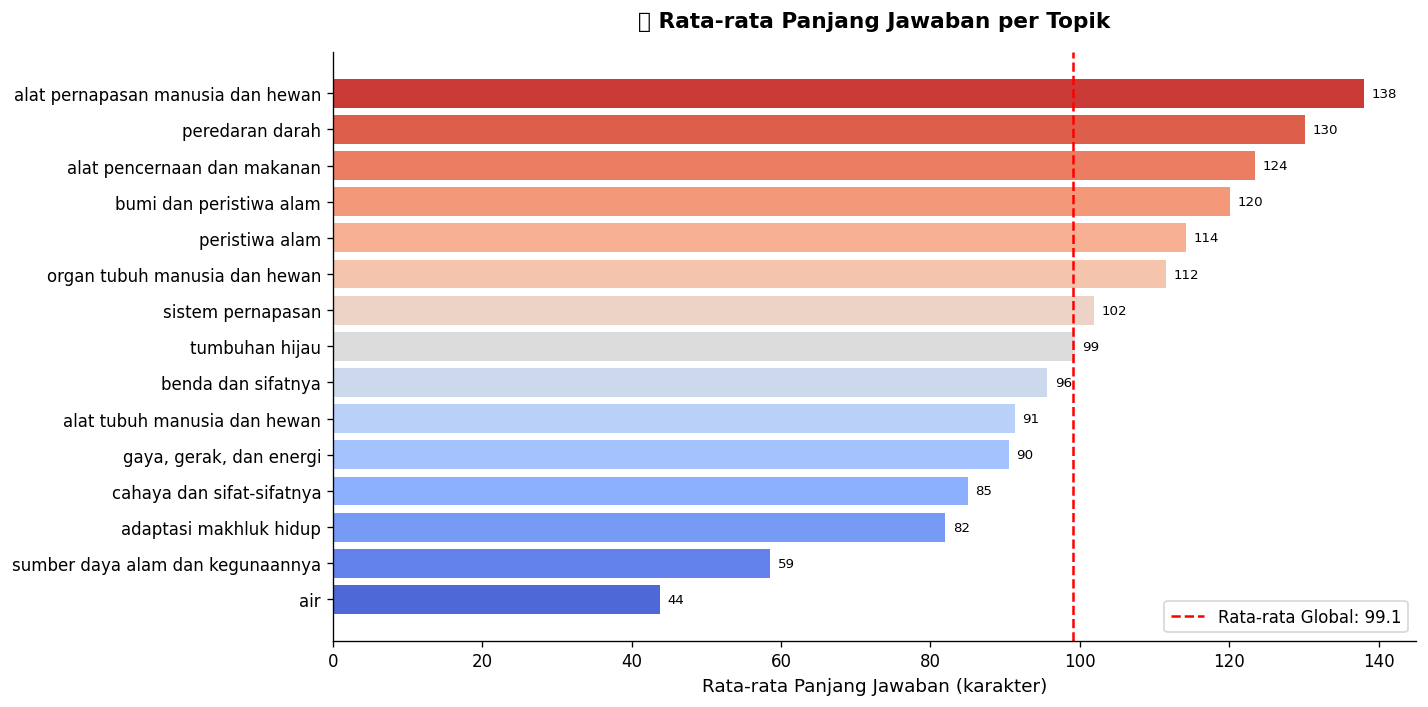

In [45]:
# --- VISUALISASI 6: Rata-rata Panjang Jawaban per Topik ---
fig, ax = plt.subplots(figsize=(12, 6))

avg_jawaban = df.groupby('topik')['panjang_jawaban'].mean().sort_values(ascending=True)
colors = sns.color_palette('coolwarm', len(avg_jawaban))

bars = ax.barh(avg_jawaban.index, avg_jawaban.values, color=colors)
ax.axvline(avg_jawaban.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Rata-rata Global: {avg_jawaban.mean():.1f}')

for bar, val in zip(bars, avg_jawaban.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', ha='left', fontsize=8)

ax.set_xlabel('Rata-rata Panjang Jawaban (karakter)', fontsize=11)
ax.set_title('📝 Rata-rata Panjang Jawaban per Topik', fontsize=13, fontweight='bold', pad=15)
ax.legend()
plt.tight_layout()
plt.savefig('viz_06_avg_jawaban_topik.png', bbox_inches='tight')
plt.show()

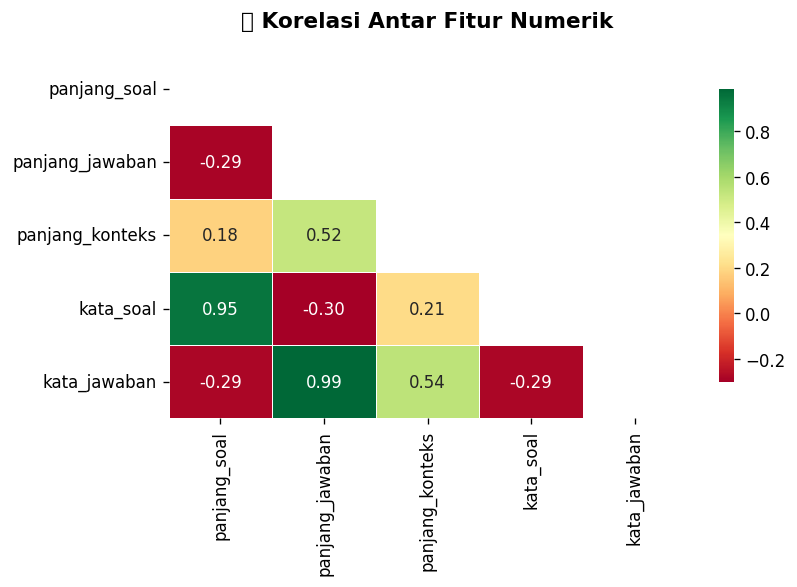

In [46]:
# --- VISUALISASI 7: Korelasi Fitur Numerik ---
fig, ax = plt.subplots(figsize=(7, 5))

num_cols = ['panjang_soal', 'panjang_jawaban', 'panjang_konteks',
            'kata_soal', 'kata_jawaban']
corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8})

ax.set_title('🔗 Korelasi Antar Fitur Numerik', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('viz_07_korelasi.png', bbox_inches='tight')
plt.show()

---
## 9️⃣ Data Dictionary

In [ ]:
data_dict = {
    'Kolom': ['no', 'topik', 'subtopik', 'soal', 'jawaban', 'contoh', 'konteks',
              'link_sumber', 'duplikat_soal', 'panjang_soal', 'panjang_jawaban', 'panjang_konteks',
              'kata_soal', 'kata_jawaban', 'jenis_pertanyaan', 'kompleksitas'],
    'Tipe': ['int', 'str', 'str', 'str', 'str', 'str', 'str',
             'str', 'bool', 'int', 'int', 'int', 'int', 'int', 'str', 'str'],
    'Deskripsi': [
        'Nomor urut soal (setelah reset)',
        'Topik utama IPA SD (sudah lowercase)',
        'Sub-topik yang lebih spesifik (sudah lowercase)',
        'Teks pertanyaan/soal',
        'Teks jawaban dari soal',
        'Contoh konkret untuk membantu pemahaman',
        'Kalimat latar belakang/konteks pertanyaan',
        'URL sumber buku ajar',
        'True jika teks kolom `soal` sama dengan salah satu baris di atasnya (occurrence pertama = False)',
        'Jumlah karakter pada kolom soal',
        'Jumlah karakter pada kolom jawaban',
        'Jumlah karakter pada kolom konteks',
        'Jumlah kata pada kolom soal',
        'Jumlah kata pada kolom jawaban',
        'Jenis pertanyaan berdasarkan kata pembuka soal',
        'Tingkat kompleksitas soal berdasarkan jumlah kata'
    ],
    'Contoh Nilai': [
        '1, 2, 3', 'alat tubuh manusia dan hewan', 'sistem pernapasan manusia',
        'sebutkan alat pernapasan pada manusia!', 'rongga hidung berfungsi...',
        'udara masuk melalui hidung...', 'manusia bernapas dengan...',
        'https://...', 'False / True', '47', '125', '60', '6', '15', 'sebutkan', 'Mudah'
    ]
}

dd_df = pd.DataFrame(data_dict)
print('📖 DATA DICTIONARY')
dd_df

📖 DATA DICTIONARY


,Kolom,Tipe,Deskripsi,Contoh Nilai
0,no,int,Nomor urut soal (setelah reset),"1, 2, 3"
1,topik,str,Topik utama IPA SD (sudah lowercase),alat tubuh manusia dan hewan
2,subtopik,str,Sub-topik yang lebih spesifik (sudah lowercase),sistem pernapasan manusia
3,soal,str,Teks pertanyaan/soal,sebutkan alat pernapasan pada manusia!
4,jawaban,str,Teks jawaban dari soal,rongga hidung berfungsi...
5,contoh,str,Contoh konkret untuk membantu pemahaman,udara masuk melalui hidung...
6,konteks,str,Kalimat latar belakang/konteks pertanyaan,manusia bernapas dengan...
7,link_sumber,str,URL sumber buku ajar,https://...
8,panjang_soal,int,Jumlah karakter pada kolom soal,47
9,panjang_jawaban,int,Jumlah karakter pada kolom jawaban,125


---
## 🔟 Export Data Bersih

In [48]:
# Export clean dataset
EXPORT_PATH = '../data_cleran/datasoal_clean.csv'
df.to_csv(EXPORT_PATH, index=False)

print('✅ Data bersih berhasil disimpan!')
print(f'📁 Path  : {EXPORT_PATH}')
print(f'📊 Shape : {df.shape}')
print(f'📋 Kolom : {df.columns.tolist()}')

✅ Data bersih berhasil disimpan!
📁 Path  : ../data_cleran/datasoal_clean.csv
📊 Shape : (2849, 15)
📋 Kolom : ['no', 'topik', 'subtopik', 'soal', 'jawaban', 'contoh', 'konteks', 'link_sumber', 'panjang_soal', 'panjang_jawaban', 'panjang_konteks', 'kata_soal', 'kata_jawaban', 'jenis_pertanyaan', 'kompleksitas']


---
## 📌 Ringkasan Temuan (Summary of Insights)

| # | Insight | Detail |
|---|---------|--------|
| 1 | **Inkonsistensi Topik** | 29 nilai unik topik → 16 topik unik setelah normalisasi (duplikat kapitalisasi) |
| 2 | **Soal Duplikat** | Baris dengan teks soal sama ditandai `duplikat_soal`; semua baris tetap ada untuk dashboard & audit |
| 3 | **Topik Terbanyak** | `alat tubuh manusia dan hewan` (131 soal) & `benda dan sifatnya` (gabungan ~200+) |
| 4 | **Panjang Soal** | Rata-rata 50 karakter (7–8 kata), distribusi normal |
| 5 | **Panjang Jawaban** | Rata-rata 99 karakter, distribusi right-skewed (ada jawaban sangat panjang) |
| 6 | **Jenis Pertanyaan** | Dominasi `sebutkan` dan `apa` — cocok untuk Q&A chatbot |
| 7 | **Kompleksitas** | Mayoritas soal tergolong `Sedang` (6–10 kata) |
| 8 | **Kesiapan Model** | Data siap digunakan sebagai input training NLP chatbot |

---
*Notebook selesai — Lanjutkan ke `dashboard.py` untuk visualisasi interaktif Streamlit.*